In [ ]:
import os
import shutil
import pandas as pd

df = pd.read_csv("metadata.csv")

img_dirs = ["images_1", "images_2"]


In [ ]:
output_dir = "dataset"

In [19]:
for label in df['dx'].unique():
    os.makedirs(os.path.join(output_dir, label), exist_ok=True)

In [20]:
for _, row in df.iterrows():
    img_name = row['image_id'] + ".jpg"
    label = row['dx']

    found = False

    for img_dir in img_dirs:
        img_path = os.path.join(img_dir, img_name)

        if os.path.exists(img_path):
            shutil.copy(img_path, os.path.join(output_dir, label, img_name))
            found = True
            break

    if not found:
        print("Missing:", img_name)

print("🔥 Dataset organized successfully")

🔥 Dataset organized successfully


In [22]:
for folder in os.listdir("data"):
    path = os.path.join("data", folder)
    print(folder, ":", len(os.listdir(path)))

akiec : 327
bcc : 514
bkl : 1099
df : 115
mel : 1113
nv : 6705
vasc : 142


In [31]:
import importlib
import preprocess

importlib.reload(preprocess)
from preprocess import load_images

In [32]:
X, y = load_images("data")

print(X.shape)
print(y.shape)

(10015, 100, 100)
(10015,)


In [64]:
import features

importlib.reload(features)
from features import extract_features
X_features = extract_features(X)

print(X_features.shape)

(10015, 7)


In [73]:
import train_model
importlib.reload(train_model)
from train_model import train_models

rf_model, svm_model, X_test, y_test = train_models(X_features, y)

--------------------------------------------------
Random Forest Accuracy: 0.618572141787319
--------------------------------------------------
--------------------------------------------------
SVM Accuracy: 0.6605092361457813
--------------------------------------------------


# Confusion Matrix

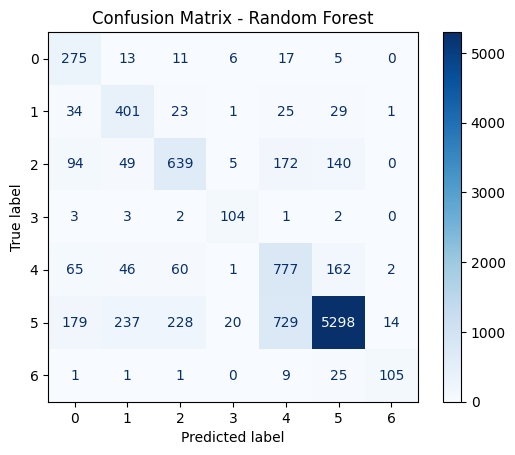

In [74]:
from sklearn.metrics import confusion_matrix,  ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_features)
cm =  confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

In [75]:
#  old ------ rf_model, svm_model = train_models(X_features, y)

rf_model, svm_model, X_test, y_test = train_models(X_scaled, y)

--------------------------------------------------
Random Forest Accuracy: 0.6270594108836745
--------------------------------------------------
--------------------------------------------------
SVM Accuracy: 0.7034448327508737
--------------------------------------------------


## Predict using scaled data

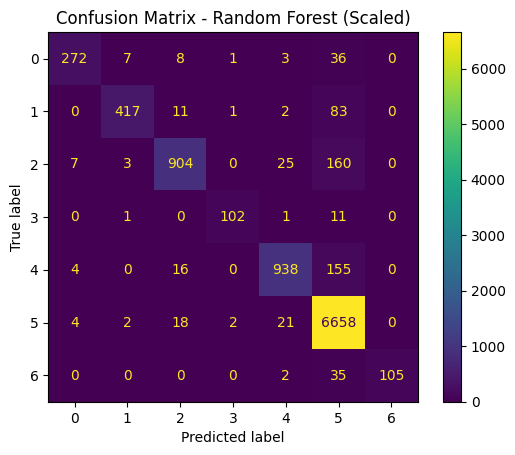

In [69]:
y_pred = rf_model.predict(X_scaled)

# Confusion matrix
cm = confusion_matrix(y, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest (Scaled)")
plt.show()

--------------------------------------------------
Random Forest Accuracy: 0.6210683974038942
--------------------------------------------------
--------------------------------------------------
SVM Accuracy: 0.7034448327508737
--------------------------------------------------


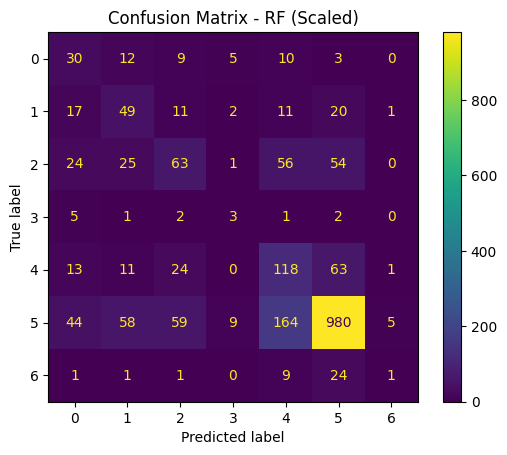

In [76]:
rf_model, svm_model, X_test, y_test = train_models(X_scaled, y)

y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix= cm)
disp.plot()
plt.title("Confusion Matrix - RF (Scaled)")
plt.show()

In [83]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

In [85]:
print(X_pca.shape)

(10015, 5)


In [86]:
rf_model, _, X_test_rf, y_test_rf = train_models(X_scaled, y)

--------------------------------------------------
Random Forest Accuracy: 0.6195706440339491
--------------------------------------------------
--------------------------------------------------
SVM Accuracy: 0.7034448327508737
--------------------------------------------------


In [87]:
_, svm_model, X_test_svm, y_test_svm = train_models(X_pca, y)

--------------------------------------------------
Random Forest Accuracy: 0.5746380429355966
--------------------------------------------------
--------------------------------------------------
SVM Accuracy: 0.6879680479281078
--------------------------------------------------


In [90]:
import pickle
pickle.dump(rf_model, open("rf_model.pkl", "wb"))